# Agentic Project Manager Workflow Experiment

This notebook experiments with the `AgenticProjectManager` agent to visualize and understand its workflow:
- Router decision-making (DIRECT vs TOOL_CALL)
- Tool execution with arguments
- Multi-turn conversation handling
- State progression from query to final answer

## 1. Setup & Initialization

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
from pprint import pprint
import json

# Load environment variables
project_root = Path.cwd().parent.parent

env_path = project_root / '.env'
load_dotenv(env_path)

print(f"Environment loaded from: {env_path}")
print(f"DATABASE_URL: {'Present' if os.getenv('DATABASE_URL') else 'Missing'}")
print(f"API_BEARER_TOKEN: {'Present' if os.getenv('API_BEARER_TOKEN') else 'Missing'}")

Environment loaded from: e:\Individual\Projects\ProMeet\.env
DATABASE_URL: Present
API_BEARER_TOKEN: Present


In [2]:
# Import agent
import sys
# Add ai_service directory to Python path
ai_service_path = project_root / 'ai_service'
if str(ai_service_path) not in sys.path:
    sys.path.insert(0, str(ai_service_path))
from src.agents.project_manager.agent import AgenticProjectManager
# Initialize agent
agent = AgenticProjectManager()
print("AgenticProjectManager initialized successfully")

e:\Individual\Projects\ProMeet\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:47: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  from google.generativeai.caching import CachedContent  # type: ignore[import]


AgenticProjectManager initialized successfully


In [3]:
# Set authentication token for API calls
from src.core.context import set_request_token

# Get token from environment (already loaded in previous cell)
api_token = os.getenv('API_BEARER_TOKEN')
if api_token:
    set_request_token(api_token)
    print("✅ Authentication token configured")
else:
    print("⚠️ Warning: No API_BEARER_TOKEN found in environment")
    print("   API calls will fail with 401 errors")

✅ Authentication token configured


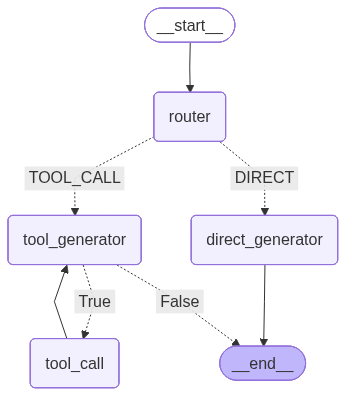


Agent Graph Visualization


In [4]:
# Visualize the agent graph
from IPython.display import Image, display

try:
    img = agent.graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print("\nAgent Graph Visualization")
except Exception as e:
    print(f"WARNING: Could not visualize graph: {e}")

## 2. Workflow Visualization Helper Functions

In [5]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
import pandas as pd
import json

def display_workflow_result(state, query):
    """Display workflow results in a single comprehensive table"""
    
    messages = state.get('messages', [])
    router_decision = state.get('router_decision', 'N/A')
    iteration_count = state.get('iteration_count', 0)
    
    # Build data for single comprehensive table
    table_data = []
    
    # Add header info
    table_data.append({
        'Field': 'Query',
        'Type': '',
        'Action': '',
        'Details': query
    })
    
    table_data.append({
        'Field': 'Router Decision',
        'Type': '',
        'Action': '',
        'Details': router_decision
    })
    
    table_data.append({
        'Field': 'Iteration Count',
        'Type': '',
        'Action': '',
        'Details': str(iteration_count)
    })
    
    # Add a separator row
    table_data.append({
        'Field': '--- Workflow Steps ---',
        'Type': '',
        'Action': '',
        'Details': ''
    })
    
    # Process all messages
    for i, msg in enumerate(messages):
        step_num = i + 1
        
        if isinstance(msg, HumanMessage):
            table_data.append({
                'Field': f'Step {step_num}',
                'Type': 'Human',
                'Action': 'User Query',
                'Details': msg.content
            })
            
        elif isinstance(msg, AIMessage):
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                for tc in msg.tool_calls:
                    tool_name = tc.get('name', 'unknown')
                    tool_args = tc.get('args', {})
                    args_str = json.dumps(tool_args, ensure_ascii=False) if tool_args else '{}'
                    table_data.append({
                        'Field': f'Step {step_num}',
                        'Type': 'AI',
                        'Action': f'Tool Call: {tool_name}',
                        'Details': f'Args: {args_str}'
                    })
            else:
                content = msg.content if msg.content else '[No content]'
                table_data.append({
                    'Field': f'Step {step_num}',
                    'Type': 'AI',
                    'Action': 'Response',
                    'Details': content
                })
                
        elif isinstance(msg, ToolMessage):
            table_data.append({
                'Field': f'Step {step_num}',
                'Type': 'Tool',
                'Action': f'Result: {msg.name}',
                'Details': msg.content
            })
    
    # Display as pandas table
    df = pd.DataFrame(table_data)
    display(df)

def display_state_messages(state):
    """Display all messages in the state with types"""
    messages = state.get('messages', [])
    
    msg_data = []
    for i, msg in enumerate(messages):
        msg_type = type(msg).__name__
        
        if isinstance(msg, (HumanMessage, AIMessage)):
            content = msg.content
        elif isinstance(msg, ToolMessage):
            content = f"Tool: {msg.name}, Content: {msg.content}"
        else:
            content = str(msg)
            
        msg_data.append({
            'Index': i,
            'Type': msg_type,
            'Content': content
        })
    
    if msg_data:
        df = pd.DataFrame(msg_data)
        display(df)

def display_tool_stats(state):
    """Display statistics about tool usage"""
    messages = state.get('messages', [])
    tool_usage = {}
    
    for msg in messages:
        if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                tool_name = tc.get('name', 'unknown')
                tool_usage[tool_name] = tool_usage.get(tool_name, 0) + 1
    
    if tool_usage:
        df = pd.DataFrame([
            {'Tool Name': name, 'Call Count': count}
            for name, count in sorted(tool_usage.items(), key=lambda x: x[1], reverse=True)
        ])
        display(df)
    else:
        print("No tools were called")

print("Helper functions loaded")


Helper functions loaded


## 3. Test Queries

Let's test the agent with different types of queries to observe various workflows.

### 3.1 Tool Call Test - Get Projects

In [9]:
# Query 1
query1 = "Tôi đang có những project nào?"
config = {"configurable": {"thread_id": "321423"}}
state1 = agent.graph.invoke(
    {"query": query1, "messages": [HumanMessage(content=query1)]},
    config=config
)

# Query 2 - SAME pattern as the API!
query2 = "project đầu có những task gì và ai đang làm nó?"
state2 = agent.graph.invoke(
    {"query": query2, "messages": [HumanMessage(content=query2)]},  # ← Pass the new message!
    config=config  # Same thread_id
)

In [10]:
display_workflow_result(state2, query2)

,Field,Type,Action,Details
0,Query,,,project đầu có những task gì và ai đang làm nó?
1,Router Decision,,,TOOL_CALL
2,Iteration Count,,,5
3,--- Workflow Steps ---,,,
4,Step 1,Human,User Query,Tôi đang có những project nào?
5,Step 2,AI,Tool Call: get_user_projects,Args: {}
6,Step 3,Tool,Result: get_user_projects,"{""success"": true, ""total"": 2, ""projects"": [{""n..."
7,Step 4,AI,Response,Bạn đang tham gia vào các dự án sau: Agentic a...
8,Step 5,Human,User Query,project đầu có những task gì và ai đang làm nó?
9,Step 6,AI,Tool Call: get_user_projects,Args: {}
